# PACS Example: Iteration 1 - Archival Service Queue Analysis with PyDASA

Single-node M/M/c/K analysis of the **PACS Image Writer Component**: 20 req/s write load (20% of 100 req/s total), serving as the dimensional analysis baseline before the full 7-node network in Iteration 2. Quality targets: $W \leq 500$ ms, $\chi \geq 20$ req/s, $\varepsilon \leq 1\%$.

We'll explore how to:

1. Define a custom dimensional framework (Time, Structure, Data).
2. Model software service variables with custom dimensions.
3. Use PyDASA's `AnalysisEngine` to derive dimensionless groups.
4. Understand the M/M/c/K queue model and operational metrics.
5. Perform sensitivity analysis and Monte Carlo simulation.
6. Visualize the "Yoly" trade-off chart for system design.

## What is the M/M/c/K Queue Model?

The **M/M/c/K** queue model is a fundamental queueing system in performance analysis:

- **M:** (Markovian arrivals): Request arrivals follow a Poisson process with rate $\lambda$.
- **M:** (Markovian service): Service times follow exponential distribution with rate $\mu$.
- **c:** Number of parallel servers (resources) available.
- **K:** Maximum system capacity (queue + servers).

### Key Performance Metrics:

**Average Waiting Time** ($W$):
$$
W = f(\lambda, \mu, c, K, L, \ldots)
$$

**Traffic Intensity** ($\tau$):
$$
\tau = \frac{\lambda}{\mu}
$$

**System Utilization** ($\rho$):
$$
\rho = \frac{\lambda}{c \cdot \mu}
$$

### Error Rate and Effective Response

The system has an error rate ($\text{err}$) that affects the effective response rate:
$$
\chi = (1 - \text{err}) \cdot \lambda
$$

Traditional queueing models often ignore error rates, but in real systems, they can significantly impact performance and user satisfaction. Incorporating $\text{err}$ allows us to model reliability and its effect on effective throughput.

Where:
- $\chi$ (chi): Effective response rate accounting for errors $[T^{-1}]$.
- $\text{err}$: Error/failure rate [dimensionless, 0 to 1].
- $\lambda$: Arrival rate $[T^{-1}]$.

**Example:** If $\lambda = 100$ req/s and $\text{err} = 0.02$ (2% error rate), then $\chi = 0.98 \times 100 = 98$ req/s successfully served.

### Custom Dimensional Framework (T, S, D)

Traditional dimensional analysis focuses on physical dimensions (M, L, T), but software systems require a different approach. By defining custom dimensions (T, S, D), we can capture the unique characteristics of software services and derive meaningful insights for design and optimization.

For software service analysis, we introduce three fundamental dimensions:
- **T** (Time): Temporal measurements [sec].
- **S** (Structure): Capacity, servers, queue slots [req].
- **D** (Data): Information content, memory [bit].

### The "Yoly" Concept

**Yoly** is a composite happiness metric that captures the trade-off between:
- **Performance:** Fast response times (low $W$).
- **Availability:** Low utilization (prevents saturation).
- **Memory Efficiency:** Optimal memory allocation.
- **Reliability:** Low error rates ($\chi/\lambda \leq 1$).

A optimal Yoly score indicates a well-balanced system configuration that keeps users happy!


## 1. Import Required Libraries

First, let's import PyDASA's core modules for dimensional analysis with custom frameworks.

In [1]:
# PyDASA imports
import pydasa
from pydasa.workflows.phenomena import AnalysisEngine
from pydasa.elements.parameter import Variable
from pydasa.dimensional.vaschy import Schema

# For visualization and analysis
import numpy as np
import matplotlib.pyplot as plt
# Import ticker for consistent axis formatting
from matplotlib.ticker import MultipleLocator
# from matplotlib.ticker import LogLocator, LogFormatterSciNotation
import random
import json

print(f"VERSION: {pydasa.__version__}")
print("PyDASA imported successfully!")

VERSION: 0.6.27
PyDASA imported successfully!


## 2. Define Custom Dimensional Framework

For software service analysis, we need a custom dimensional framework that captures the unique characteristics of queueing systems. Unlike physical systems (Length, Mass, Time), we define the following fundamental dimensional units:

**Custom Framework Definition:**

1. **T (Time):** Temporal measurements.
   - Unit: seconds $[s]$
   - Examples: waiting time, service time, inter-arrival time
   - Physical analogy: Similar to Time $[T]$ in physical systems.

2. **S (Structure):** System capacity and architectural elements.
   - Unit: requests $[req]$
   - Examples: number of requests/reply a server can handle, queue positions, concurrent requests
   - Software-specific: Represents discrete structural resources, proxy for the effort to complete operations, related to Mass $[M]$ and Length $[L]$ in physical systems.

3. **D (Data):** Information content and memory
   - Unit: bits $[bit]$.
   - Examples: request payload size, buffer memory, data throughput.
   - Software-specific: Quantifies information processing.

This framework allows us to perform dimensional analysis on software services, deriving dimensionless numbers that characterize system behavior independent of scale.

In [2]:
# Define custom Fundamental Dimensional Units (FDUs) for software service analysis
fdu_list = [
    {
        "_idx": 0,
        "_sym": "T",
        "_fwk": "CUSTOM",
        "description": "Temporal measurements",
        "_unit": "s",
        "_name": "Time"
    },
    {
        "_idx": 1,
        "_sym": "S",
        "_fwk": "CUSTOM",
        "description": "Structural complexity of the operations",
        "_unit": "req",
        "_name": "Structure"
    },
    {
        "_idx": 2,
        "_sym": "D",
        "_fwk": "CUSTOM",
        "description": "Information content and memory",
        "_unit": "bit",
        "_name": "Data"
    }
]

# Create custom schema with T, S, D framework
schema = Schema(_fwk="CUSTOM",
                _fdu_lt=fdu_list, _idx=0)   # type: ignore
schema._setup_fdus()

print("=== Custom Framework Created Successfully! ===")
print(f"\tFramework: {schema.fwk}")
print(f"\tNumber of FDUs: {len(schema._fdu_lt)}")
print("\nFundamental Dimensional Units:")
print(f"{'Symbol':<10} {'Name':<15} {'Unit':<10} {'Description':<55}")
print("-" * 80)
for fdu in schema._fdu_lt:
    print(f"{fdu._sym:<10} {fdu._name:<15} {fdu._unit:<10} {fdu.description[:60]}")

=== Custom Framework Created Successfully! ===
	Framework: CUSTOM
	Number of FDUs: 3

Fundamental Dimensional Units:
Symbol     Name            Unit       Description                                            
--------------------------------------------------------------------------------
T          Time            s          Temporal measurements
S          Structure       req        Structural complexity of the operations
D          Data            bit        Information content and memory


## 3. Define Queue Model Variables

*Variables represent the Image Writer Component (AWS) node: $\lambda_{AWS} = 20$ req/s, payload $\rho_{\text{req}} \in [1, 16]$ MB/req (X-ray to MRI), buffer $M_\text{buf} = K \times \rho_{\text{req}}$.*

We'll define 11 variables for the M/M/c/K queueing system with proper dimensions using the custom T, S, D framework.

**Variable Categories:**

**INPUT Variables (3)** - Primary system parameters:
1. $\lambda$ (lambda): Arrival rate $[S \dot T^{-1}]$
2. $K$: Maximum queue capacity $[S]$
3. $\rho_{\text{req}}$: Data density per request $[D * S^{-1}]$

**OUTPUT Variable (1)** - Performance metric we want to analyze:
1. $W$: Average waiting time $[T]$

**CONTROL Variables (7)** - System configuration and secondary parameters:
1. $L$: Average queue length $[S]$
2. $\mu$ (mu): Service rate $[S/T]$
3. $c$: Number of parallel servers $[S]$
4. ${M_\text{buf}}$: Buffer allocated memory $[D]$, where $M_\text{buf} = \rho_{\text{req}} \cdot K$
5. ${M_\text{act}}$: Data used in processing $[D]$, where $M_\text{act} = \rho_{\text{req}} \cdot L$
6. $\text{err}$: Error/failure rate [n.a.]
7. $\chi$ (chi): Effective response rate $[S/T]$, where $\chi = (1 - \text{err}) \times \lambda$

**Typical Values for the PACS Archival Service:**
- Arrival rate: 20 req/s ($\lambda_{AWS} = 0.20 \times 100$ req/s)
- Service rate: 200 req/s for slow servers, 500 req/s for mid-tier servers, 1000 req/s for fast servers
- Servers: up to 4 parallel processors
- Queue capacity: up to 16 requests
- Buffer memory: 32.0 MB
- Data per request: 1-16 MB (X-ray ~1 MB, CT ~2-4 MB, MRI ~8-16 MB)
- Error rate: 1.0% (0.01), equivalent to 99.0% success rate, or 2 $\sigma$
- Expected average queue length: 3 requests
- Expected waiting time: 50 ms


In [3]:
# Define the queueing system variables as dictionaries
# Each variable is stored with its symbol as the key
# load from JSON file

fn = "data/PACS-vars-iter1.json"
with open(fn, mode="r", encoding="utf-8") as f:
    variables_dict = json.load(f)

print(f"Loaded {len(variables_dict)} variables from {fn}")

# INPUT VARIABLES (3)
# \\lambda_{s}: Arrival rate [S/T]: requests arriving per unit time
# K: Queue capacity [S]: maximum system capacity
# \\rho_{req}: Data density [D/S]: data per request

# OUTPUT VARIABLE (1)
# L: Queue length [S]: average number in queue

# CONTROL VARIABLES (7)
# W: Waiting time [T]: average time in queue
# \\mu_{s}: Service rate [S/T]: requests served per unit time
# \\chi_{s}: Response rate [S/T]: effective throughput
# \\chi_{s} = \\lambda_{s} (1 - err) [S/T]: effective arrival rate, depends on error rate and arrival rate
# c: Servers [S]: number of parallel servers
# M_{act}: Active memory [D]: memory used by active/in queue requests
# M_{MAX}: Max Buffer memory [D]: allocated memory

# NOT RELEVANT for dimensional analysis
# err: Error rate [dimensionless]: failure probability NOT relevant for dimensional mqatrix but important for performance analysis
# Wq: Waiting time in queue [T]: time spent waiting (not including service time)
# Lq: Queue length in queue [S]: number of requests waiting (not including those being served)

Loaded 13 variables from data/PACS-vars-iter1.json


In [4]:
# Q(M/M/c/K) queueing system variables:
# - \\lambda_{s}: Arrival rate (S/T) = 100 req/s
# - K: Queue capacity (S) = 8 req
# - c: Servers (S) = 1
# - \\mu_{s}: Service rate (S/T) = 400 req/s
# other control variables:
# - \\rho_{req}: Data density (D/S) = 5000 kB/req
# - M_{MAX}: MAX Buffer memory (D) = 32 MB
# - M_{act}: Active memory (D) = 8 MB
# - err: Error rate (dimensionless) = 0.03 (3% failure rate)
# - \\chi_{s}: Response rate (S/T) = 97 req/s (calculated as (1 - err) × λ)
# Outputs (calculated from M/M/c/K formulas and error rate):
# - W: Waiting time (T) = 0.005 s
# - L: Queue length (S) = 0.9946 req

# Convert dictionaries to Variable instances
variables = {
    sym: Variable(**params) for sym, params in variables_dict.items()
}

print("=== Variables defined ===")
print(f"\t- Total: {len(variables)}")
print(f"\t- Relevant for dimensional analysis: {sum(1 for v in variables.values() if v.relevant)}")
print(f"\t- Not relevant variables: {sum(1 for v in variables.values() if not v.relevant)}")

print("\nVariable Details:")
title = f"{'Symbol':<15} {'Setpoint':<20} {'Units':<10} {'Dimensions':<20} "
title += f"{'Category':<10} {'Relevant':<10}"
print(title)
print("-" * 95)
for sym, var in variables.items():
    dims_str = var.dims if var.dims else "(N.A.)"
    relevant_str = "True" if var.relevant else "False"
    setpoint_str = str(var.setpoint) if var.setpoint is not None else "N/A"
    print(f"{sym:<15} {setpoint_str:<20} {var.units:<10} {dims_str:<20} {var.cat:<10} {relevant_str:<10}")
print("-" * 95)

=== Variables defined ===
	- Total: 13
	- Relevant for dimensional analysis: 10
	- Not relevant variables: 3

Variable Details:
Symbol          Setpoint             Units      Dimensions           Category   Relevant  
-----------------------------------------------------------------------------------------------
\lambda_{AS}    100.0                req/s      S*T^-1               IN         True      
\mu_{AS}        400.0                req/s      S*T^-1               CTRL       True      
\epsilon_{AS}   0.01                 %          (N.A.)               CTRL       False     
\chi_{AS}       99.0                 req/s      S*T^-1               CTRL       True      
c_{AS}          1.0                  req        S                    CTRL       True      
K_{AS}          8.0                  req        S                    IN         True      
\rho_{req}      5000.0               kB/req     D*S^-1               IN         True      
L_{AS}          0.9946               req        

## 3. Create Dimensional Analysis Engine

Now we'll use PyDASA's **AnalysisEngine** (main workflow) to automatically derive dimensionless groups using the Buckingham Pi theorem.

In [5]:
# Create the dimensional analysis engine
engine = AnalysisEngine(
    _idx=0,
    _fwk="CUSTOM",
    _schema=schema,
    _name="Software Service Analysis",
    description="Dimensional analysis for the Yoly Chart and the queue model M/M/c/K."
)

# Add all variables to the engine
engine.variables = variables
print("=" * 50)
print("============= AnalysisEngine Created =============")
print("=" * 50)

print(f"\t- Framework: {engine.fwk}")
print(f"\t- Variables: {len(variables)}\n")

print("Variable Categories:")
print("-" * 50)
n_inputs = sum(1 for v in variables.values() if v.cat == "IN")
print(f"\t- Input variables: {n_inputs}")
n_outputs = sum(1 for v in variables.values() if v.cat == "OUT")
print(f"\t- Output variables: {n_outputs}")
n_controls = sum(1 for v in variables.values() if v.cat == "CTRL")
print(f"\t- Control variables: {n_controls}")
print("-" * 50)

============= AnalysisEngine Created =============
	- Framework: CUSTOM
	- Variables: 13

Variable Categories:
--------------------------------------------------
	- Input variables: 3
	- Output variables: 1
	- Control variables: 9
--------------------------------------------------


## 4. Run Dimensional Analysis

Execute the complete workflow to generate dimensionless coefficients (Pi groups).

In [6]:
# Run the complete dimensional analysis workflow
results = engine.run_analysis()

print("=" * 50)
print("=============== Analysis complete! ===============")
print("=" * 50)

print(f"\tNumber of Dimensionless Groups: {len(engine.coefficients)}")
print(f"\tCoefficients generated: {list(engine.coefficients.keys())}\n")

# Display coefficients in a formatted table
print("Dimensionless Coefficients Details:")
print("=" * 100)
print(f"{'Coefficient':<15} {'Expression':<35} {'Variable Exponents':<60}")
print("=" * 100)

for name, coeff in engine.coefficients.items():
    # Extract the coefficient expression
    expression = str(coeff.pi_expr) if len(str(coeff.pi_expr)) < 35 else str(coeff.pi_expr)[:32] + "..."
    
    # Format variable exponents as a compact string
    exponents_str = ", ".join([f"{var}^{exp}" if exp != 1 else var
                               for var, exp in coeff.var_dims.items()])
    if len(exponents_str) > 58:
        exponents_str = exponents_str[:55] + "..."
    
    print(f"{name:<15} {expression:<35} {exponents_str:<60}")

print("=" * 100)

=============== Analysis complete! ===============
	Number of Dimensionless Groups: 7
	Coefficients generated: ['\\Pi_{0}', '\\Pi_{1}', '\\Pi_{2}', '\\Pi_{3}', '\\Pi_{4}', '\\Pi_{5}', '\\Pi_{6}']

Dimensionless Coefficients Details:
Coefficient     Expression                          Variable Exponents                                          
\Pi_{0}         \frac{L_{AS}}{K_{AS}}               K_{AS}^-1, L_{AS}                                           
\Pi_{1}         \frac{\mu_{AS}}{\lambda_{AS}}       \lambda_{AS}^-1, \mu_{AS}                                   
\Pi_{2}         \frac{\chi_{AS}}{\lambda_{AS}}      \lambda_{AS}^-1, \chi_{AS}                                  
\Pi_{3}         \frac{c_{AS}}{K_{AS}}               K_{AS}^-1, c_{AS}                                           
\Pi_{4}         \frac{\lambda_{AS}*W_{AS}}{K_{AS}}  \lambda_{AS}, K_{AS}^-1, W_{AS}                             
\Pi_{5}         \frac{M_{act_{AS}}}{K_{AS}*\rho_... K_{AS}^-1, \rho_{req}^-1, M_{act_{AS}

## 5. Derive Key Dimensionless Coefficients

Now let's use PyDASA's `derive_coefficient()` method to create operationally meaningful coefficients from the Pi groups. Thus, we expect to see:

1. **Occupancy Coefficient** ($\theta$): Queue capacity utilization.
   - $\theta = \Pi_0 = L/K$
2. **Stall Coefficient** ($\sigma$): Service blocking indicator.
   - $\sigma = \Pi_1 = W \cdot \lambda / L$
3. **Effective-Yield Coefficient** ($\eta$): Resource utilization effectiveness
   - $\eta = \Pi_2^{-1} \cdot \Pi_3 \cdot \Pi_4^{-1} = \chi \cdot K / (\mu \cdot c)$
4. **Memory Coefficient** ($\phi$): Data usage metric.
   - $\phi = \Pi_5 \cdot \Pi_6^{-1} = M_{\text{act}} / B_{\text{MAX}}$

Also remember the complementary functions:
- **Little's Law:** $L = \lambda \cdot W$
- **Data Payload:** $B = \rho_{req} \cdot L$
- **Effective Departure Rate:** $\chi = (1 - \text{err}) \cdot \lambda$

These derived coefficients connect directly to the Yoly diagram we'll construct.

In [7]:
# Get the original Pi coefficients
pi_keys = list(engine.coefficients.keys())

# Derive Occupancy Coefficient: θ = Π₀ = L/K
delta_coeff = engine.derive_coefficient(
    expr=f"{pi_keys[0]}",
    symbol="\\theta_{AS}",
    name="Archival Occupancy Coefficient",
    description="θ = L/K - Queue occupancy ratio (0 = empty, 1 = full)",
    idx=-1
)

# Derive Stall Coefficient: σ = Π₄ = W·λ/L
sigma_coeff = engine.derive_coefficient(
    expr=f"{pi_keys[4]}",
    symbol="\\sigma_{AS}",
    name="Archival Stall Coefficient",
    description="σ = W·λ/L - Service stall/blocking indicator",
    idx=-1
)

# Derive Effective-Yield Coefficient: η = Π₁⁻¹·Π₂·Π₃⁻¹ = χ·K/(μ·c)
eta_coeff = engine.derive_coefficient(
    # expr=f"{pi_keys[2]} * {pi_keys[3]}**(-1) * {pi_keys[4]}",
    expr=f"{pi_keys[1]}**(-1) * {pi_keys[2]} * {pi_keys[3]}**(-1)",
    symbol="\\eta_{AS}",
    name="Archival Effective-Yield Coefficient",
    description="η = χ·K/(μ·c) - Resource utilization effectiveness",
    idx=-1
)

# Derive Memory-Usage Coefficient: φ = Π₅·Π₆⁻¹ = M_act/M_buf
phi_coeff = engine.derive_coefficient(
    expr=f"{pi_keys[5]} * {pi_keys[6]}**(-1)",
    symbol="\\phi_{AS}",
    name="Archival Memory-Usage Coefficient",
    description="φ = Mact/Mbuf - Data usage metric",
    idx=-1
)

# Calculate numerical values using stored setpoints
delta_val = delta_coeff.calculate_setpoint()
sigma_val = sigma_coeff.calculate_setpoint()
eta_sim = eta_coeff.calculate_setpoint()
phi_val = phi_coeff.calculate_setpoint()

# Display results
print("=" * 120)
print("DERIVED DIMENSIONLESS COEFFICIENTS")
print("=" * 120)
print(f"{'Coefficient':<25} {'Expression':<45} {'Value':<15} {'Description':<35}")
print("=" * 120)
print(f"{'Occupancy (θ)':<25} {str(delta_coeff.pi_expr):<45} {delta_val:<15.4f} {'Queue capacity utilization':<35}")
print(f"{'Stall (σ)':<25} {str(sigma_coeff.pi_expr)[:45]:<45} {sigma_val:<15.4f} {'Service blocking indicator':<35}")
print(f"{'Effective-Yield (η)':<25} {str(eta_coeff.pi_expr)[:45]:<45} {eta_sim:<15.4f} {'Resource utilization':<35}")
print(f"{'Memory-Usage (φ)':<25} {str(phi_coeff.pi_expr):<45} {phi_val:<15.4f} {'Data density metric':<35}")
print("=" * 120)

# Interpret values for operational insights
print("\nTRADITIONAL QUEUE OPERATIONAL ASSESSMENT")
print("=" * 120)

# traffic intensity: t = λ/μ
lambda_s = variables["\\lambda_{AS}"].setpoint
mu_s = variables["\\mu_{AS}"].setpoint
theta = lambda_s / mu_s    # type: ignore
print(f"Traffic Intensity (θ = λ/μ) = {theta:.2f}")

# utilization: ρ = λ/(c·μ)
c = variables["c_{AS}"].setpoint
rho = lambda_s / (c* mu_s)    # type: ignore
print(f"Utilization (ρ = λ/(c·μ)) = {rho:.2f}")

# Occupancy L/K
L = variables["L_{AS}"].setpoint
K = variables["K_{AS}"].setpoint
occupancy = L / K    # type: ignore
print(f"Occupancy (θ = L/K) = {occupancy:.4f}")

# Memory usagge: M_act/M_buf
M_act = variables["M_{act_{AS}}"].setpoint
M_buf = variables["M_{buf_{AS}}"].setpoint
memory_usage = M_act / M_buf    # type: ignore
print(f"Memory Usage (φ = M_act/M_buf) = {memory_usage:.4f}")

DERIVED DIMENSIONLESS COEFFICIENTS
Coefficient               Expression                                    Value           Description                        
Occupancy (θ)             \frac{L_{AS}}{K_{AS}}                         0.1243          Queue capacity utilization         
Stall (σ)                 \frac{\lambda_{AS}*W_{AS}}{K_{AS}}            0.0625          Service blocking indicator         
Effective-Yield (η)       \frac{K_{AS}*\chi_{AS}}{\mu_{AS}*c_{AS}}      1.5840          Resource utilization               
Memory-Usage (φ)          \frac{M_{act_{AS}}}{M_{buf_{AS}}}             0.5000          Data density metric                

TRADITIONAL QUEUE OPERATIONAL ASSESSMENT
Traffic Intensity (θ = λ/μ) = 0.25
Utilization (ρ = λ/(c·μ)) = 0.25
Occupancy (θ = L/K) = 0.1243
Memory Usage (φ = M_act/M_buf) = 0.3438


## 7. Run Sensitivity Analysis

Let's use PyDASA's **SensitivityAnalysis** workflow to understand which variables have the most influence on our dimensionless coefficients.

In [8]:
from pydasa.workflows.influence import SensitivityAnalysis

# Create sensitivity analysis handler
sensitivity = SensitivityAnalysis(
    _idx=0,
    _fwk="CUSTOM",
    _schema=schema,
    _name="Queue Model Sensitivity Analysis",
    _cat="SYM"  # Symbolic sensitivity analysis
)

# Configure with variables and coefficients from the engine
sensitivity.variables = engine.variables
sensitivity.coefficients = engine.coefficients

print("=== SensitivityAnalysis workflow created ===")
print(f"\tFramework: {sensitivity.fwk}")
print(f"\tAnalysis type: {sensitivity.cat} (Symbolic)")
print(f"\tVariables: {len(sensitivity.variables)}")
print(f"\tCoefficients to analyze: {len(sensitivity.coefficients)}")

# Run symbolic sensitivity analysis at mean values
print("\n--- Running Symbolic Sensitivity Analysis ---")
sensitivity_results = sensitivity.analyze_symbolic(val_type="mean")

print(f"=== Symbolic sensitivity analysis complete! ===")
print(f"\tAnalyzed {len(sensitivity_results)} coefficients")
print(f"\tResults available for: {list(sensitivity_results.keys())}")

=== SensitivityAnalysis workflow created ===
	Framework: CUSTOM
	Analysis type: SYM (Symbolic)
	Variables: 13
	Coefficients to analyze: 11

--- Running Symbolic Sensitivity Analysis ---
=== Symbolic sensitivity analysis complete! ===
	Analyzed 11 coefficients
	Results available for: ['SEN_{\\Pi_{0}}', 'SEN_{\\Pi_{1}}', 'SEN_{\\Pi_{2}}', 'SEN_{\\Pi_{3}}', 'SEN_{\\Pi_{4}}', 'SEN_{\\Pi_{5}}', 'SEN_{\\Pi_{6}}', 'SEN_{\\theta_{AS}}', 'SEN_{\\sigma_{AS}}', 'SEN_{\\eta_{AS}}', 'SEN_{\\phi_{AS}}']


In [9]:
# Display sensitivity analysis results in formatted tables
print("=" * 120)
print("SENSITIVITY ANALYSIS RESULTS - Symbolic Differentiation at Mean Values")
print("=" * 120)

# Get the derived coefficients we care about (σ, θ \, η, φ)
derived_coeff_keys = [
    k for k in sensitivity_results.keys() if not k.startswith("SEN_{\\Pi")
]

for coeff_key in derived_coeff_keys:
    sens_data = sensitivity_results[coeff_key]
    
    # Get coefficient name
    if coeff_key in engine.coefficients:
        coeff_name = engine.coefficients[coeff_key].name
    else:
        coeff_name = coeff_key
    
    print(f"\n{'Coefficient':<25} {coeff_key:<20} ({coeff_name})")
    print("-" * 120)
    print(f"{'Variable':<20} {'Sensitivity':<20} {'Relative Impact (%)':<25} {'Description':<55}")
    print("-" * 120)
    
    # Calculate total sensitivity for relative percentages
    total_sens = sum(abs(v) for v in sens_data.values() if isinstance(v, (int, float)))
    
    # Sort by absolute sensitivity (descending)
    sorted_vars = sorted(sens_data.items(), key=lambda x: abs(x[1]) if isinstance(x[1], (int, float)) else 0, reverse=True)
    
    for var_sym, sens_val in sorted_vars:
        if isinstance(sens_val, (int, float)):
            # Get variable name
            if var_sym in engine.variables:
                var_name = engine.variables[var_sym].name
            else:
                var_name = var_sym
            
            # Calculate relative impact
            rel_impact = (abs(sens_val) / total_sens * 100) if total_sens > 0 else 0
            
            # Format sensitivity value
            sens_str = f"{sens_val:+.4e}"
            
            # Impact description
            if rel_impact > 40:
                impact_desc = "🔴 DOMINANT influence"
            elif rel_impact > 20:
                impact_desc = "🟠 MAJOR influence"
            elif rel_impact > 10:
                impact_desc = "🟡 MODERATE influence"
            else:
                impact_desc = "🟢 MINOR influence"
            
            print(f"{var_sym:<20} {sens_str:<20} {rel_impact:<25.2f} {impact_desc:<55}")

print("\n" + "=" * 120)

SENSITIVITY ANALYSIS RESULTS - Symbolic Differentiation at Mean Values

Coefficient               SEN_{\theta_{AS}}    (SEN_{\theta_{AS}})
------------------------------------------------------------------------------------------------------------------------
Variable             Sensitivity          Relative Impact (%)       Description                                            
------------------------------------------------------------------------------------------------------------------------
L_{AS}               +1.2500e-01          88.94                     🔴 DOMINANT influence                                   
K_{AS}               -1.5541e-02          11.06                     🟡 MODERATE influence                                   

Coefficient               SEN_{\sigma_{AS}}    (SEN_{\sigma_{AS}})
------------------------------------------------------------------------------------------------------------------------
Variable             Sensitivity          Relative Impact 

## 8. Generate Grid-Based Simulation Data

Instead of random sampling, we'll generate structured data points by systematically varying queue parameters:

**Strategy:** Grid search over configurations while varying arrival rate ($\lambda$) until near-saturation

**Configuration Parameters:**
- $K$ (Capacity) = [4, 8, 16] req → 3 values
- $\mu$ (Service rate): [200, 500, 1000] req/s → 3 values  
- $c$ (Servers): [1, 2, 4] req → 3 values
- **Total configurations:** 3 × 3 × 3 = **27 configurations**

**Constants:**
- $\text{err}$ (Error rate): 0.01 (1% failure rate)
- $M_{\text{buf}}$ (Buffer Memory) = 32 MB (fixed, equivalent to $2.56 \times 10^8$ bits)
- $\rho_{\text{req}}$ (Data density) = from 100 kB/req to 10 MB/req (equivalent to $8 \times 10^5$ bits/req to $8 \times 10^7$ bits/req) varied to analyze data impact.

**Rho Sweep Strategy:**
- Start: $\rho_{\text{req}} = 8 \times 10^5$ bits/req$ (100 kB/req)
- Stop: $\rho_{\text{req}} = 8 \times 10^7$ bits/req$ (10 MB/req)
- Step: $\Delta\rho_{\text{req}} = 2.5 \times 10^6$ bits/req$ (312.5 kB/req) 

**Lambda Sweep Strategy:**
- Start: $\lambda_{0} = 100$ req/s (from std_min)
- Stop: When $\rho = \lambda/(c \cdot \mu) \geq 0.95$ (near-saturation, avoid instability)
- Step: $\Delta\lambda = 10$ req/s

**For each configuration**, we'll:
1. Vary $\lambda$ from 100 to saturation point ($\rho \geq 0.95$)
2. Calculate $\chi = (1 - \text{err}) \times \lambda$
3. Use M/M/c/K queueing model to compute $W$ and $L$
4. Store all variable values for PyDASA analysis

In [10]:
from src.queueing import Queue
import itertools
import pandas as pd

# STEP A: Generate Configuration Grid
# ====================================
print("=" * 80)
print("STEP A: Generating Configuration Grid")
print("=" * 80)
# iterate over the following parameters:
# lambda_s: from 100 to overflow state

# for the grid-search we iterate over the following parameters:
# K: queue capacity wih 4, 8 and 16
K_values = [4, 8, 16]

# c: number of servers with 1, 2, 4
c_values = [1, 2, 4]

# mu: 200, 500 an 1000 for slow, medium and fast services
mu_values = [200, 500, 1000]

# the constants are:
M_BUF = 2.56e8 # Max Buffer Memory [32 MB]

# err: 1% as 2 sigma in QoS agreement.
ERR = 0.01     # Error rate [%]

# rho_zero: 1 MB/req as data density for the grid search
rho_zero = 8e6      # Data density [bit/req] (1 MB = 8e6 bits)
# rho_step = 1e6*11    # Data density step [bit/req] (312.5 kB/req)

# initial active memory
K_zero = M_BUF / rho_zero  # queue capacity starting point based on buffer and data density (32 MB / 1 MB/req = 32 req)

# lamba_zero: arrival rate starting point: 100 req/s
lambda_zero = 100  # Arrival rate [req/s]
lambda_step = 10    # Arrival rate step [req/s]

# generate paired (K, rho) values maintaining M_BUF = K × rho
# this ensures buffer memory remains constant across all configurations
K_rho_pairs = []
for K in K_values:
    rho_K = M_BUF / K  # Data density based on buffer and queue capacity
    K_rho_pairs.append((K, rho_K))

msg = f"\nGenerated {len(K_rho_pairs)} (K, ρ) pairs maintaining "
msg += f"M_BUF = K × ρ = {M_BUF:.2e} bits:"
print(msg)
for K, rho in K_rho_pairs:
    print(f"  K={K:3d} req  →  ρ={rho:.2e} bit/req  →  M_BUF={K*rho:.2e} bits")

# Generate all combinations using Cartesian product
# Keep (K, rho) paired, but combine with all (c, mu) values
cfg_lt = []
for (K, rho) in K_rho_pairs:
    for c in c_values:
        for mu in mu_values:
            cfg_lt.append((K, rho, c, mu))

print(f"\nGenerated {len(cfg_lt)} configurations:")
print(f"  - {len(K_rho_pairs)} (K, ρ) pairs × {len(c_values)} servers × {len(mu_values)} service rates")
print(f"  - Total: {len(K_rho_pairs)} × {len(c_values)} × {len(mu_values)} = {len(cfg_lt)} configurations")

title = f"{'Config #':<10} {'K (Capacity)':<15} {'ρ (Data Density)':<20}"
title += f"{'c (Servers)':<15} {'μ (Service Rate)':<20}"
print(f"\n{title}")
print("-" * 80)
for idx, (K_val, rho_val, c_val, mu_val) in enumerate(cfg_lt):
    msg = f"{idx:<10} {K_val:<15} {rho_val:<20.2e} {c_val:<15} {mu_val:<20}"
    print(msg)

STEP A: Generating Configuration Grid

Generated 3 (K, ρ) pairs maintaining M_BUF = K × ρ = 2.56e+08 bits:
  K=  4 req  →  ρ=6.40e+07 bit/req  →  M_BUF=2.56e+08 bits
  K=  8 req  →  ρ=3.20e+07 bit/req  →  M_BUF=2.56e+08 bits
  K= 16 req  →  ρ=1.60e+07 bit/req  →  M_BUF=2.56e+08 bits

Generated 27 configurations:
  - 3 (K, ρ) pairs × 3 servers × 3 service rates
  - Total: 3 × 3 × 3 = 27 configurations

Config #   K (Capacity)    ρ (Data Density)    c (Servers)     μ (Service Rate)    
--------------------------------------------------------------------------------
0          4               6.40e+07             1               200                 
1          4               6.40e+07             1               500                 
2          4               6.40e+07             1               1000                
3          4               6.40e+07             2               200                 
4          4               6.40e+07             2               500                 
5    

In [11]:
print("=" * 60)
print(f"== Configuration grid ready: {len(cfg_lt)} configurations ==")
print("=" * 60)

print("\nSimulation Constants:")
print("-" * 60)
print(f"\t- Buffer Memory (M_buf): {M_BUF:+.4e} [bit]")
print(f"\t- Data Density (ρ_zero): {rho_zero:+.4e} [bit/req]")
print(f"\t- Error Rate (err): {ERR * 100:.2f} [%]")      # type: ignore
print(f"\t- Arrival Rate (λ₀): {lambda_zero:.1f} [req/s]")
print(f"\t- Arrival Rate Step (Δλ): {lambda_step:.1f} [req/s]")

# STEP B: Create DataFrame for Queue Variables
# =============================================
print("\n" + "=" * 60)
print("STEP B: Creating Queue Model DataFrame")
print("=" * 60)

# export the keys of the relevan vars
q_cols = [var._sym for var in variables.values() if var.relevant]
# reintroduicing error
err = "\\epsilon_{AS}"
if err not in q_cols:
    q_cols.append(err)

# q_cols = list(variables.keys())
data_df = pd.DataFrame(columns=q_cols)
print(f"DataFrame created with columns: {q_cols}")
print(f"\t- DataFrame columns: {len(q_cols)} variables")
print(f"\t- Initial shape: {data_df.shape}")
print("=" * 60)

== Configuration grid ready: 27 configurations ==

Simulation Constants:
------------------------------------------------------------
	- Buffer Memory (M_buf): +2.5600e+08 [bit]
	- Data Density (ρ_zero): +8.0000e+06 [bit/req]
	- Error Rate (err): 1.00 [%]
	- Arrival Rate (λ₀): 100.0 [req/s]
	- Arrival Rate Step (Δλ): 10.0 [req/s]

STEP B: Creating Queue Model DataFrame
DataFrame created with columns: ['\\lambda_{AS}', '\\mu_{AS}', '\\chi_{AS}', 'c_{AS}', 'K_{AS}', '\\rho_{req}', 'L_{AS}', 'W_{AS}', 'M_{act_{AS}}', 'M_{buf_{AS}}', '\\epsilon_{AS}']
	- DataFrame columns: 11 variables
	- Initial shape: (0, 11)


In [12]:
# STEP C: Generate Data Points with M/M/c/K Model
# ================================================

# calculate the following values for the grid search:
# W: waiting time in queue
# L: queue length

print("=" * 60)
print("STEP C: Generating Data with M/M/c/K Queueing Model")
print("=" * 60)

print("\nPrinting progress every 10 configurations...\n")

UTIL_THLD = 0.95  # Stop when utilization reaches 95.0%

# Process each configuration
for idx, (K, rho, c, mu) in enumerate(cfg_lt, 1):

    lambda_t = lambda_zero
    util_t = 0.0
    i = 0

    while util_t < UTIL_THLD:
        # Create and evaluate M/M/c/K queue model
        q = Queue(
            "M/M/c/K",
            _lambda=lambda_t,   # type: ignore
            mu=mu,              # type: ignore
            n_servers=c,        # type: ignore
            kapacity=K          # type: ignore
        )
        q.calculate_metrics()
        chi_t = lambda_t * (1 - ERR)    # type: ignore
        M_act = q.avg_len * rho         # type: ignore

        # Store data point
        #'\\lambda', '\\mu', '\\chi', 'c', 'K', '\\rho_{req}', 'L', 'W', 'M_{act}', 'M_{buf}', '\\epsilon']

        data_t = [
            lambda_t,
            mu,
            chi_t,
            c,
            K,
            rho,
            q.avg_len,
            q.avg_wait,
            M_act,
            M_BUF,
            ERR,
        ]
        # print(len(data_t), data_t)
        data_df.loc[len(data_df)] = data_t

        util_t = q.rho  # try no to confuse utilization with data density
        lambda_t = lambda_t + lambda_step   # type: ignore
        i += 1

    if idx % 5 == 0:
        cfg = f"Config {idx}/{len(cfg_lt)}: K={K}, ρ={rho:.2e}, c={c}, μ={mu}"
        print(f"--- Processing {cfg} ---")
        print(f"\t- OK: Generated {i} data points for configuration {idx}")
print(f"\n=============== Data generation complete! ==================")

STEP C: Generating Data with M/M/c/K Queueing Model

Printing progress every 10 configurations...

--- Processing Config 5/27: K=4, ρ=6.40e+07, c=2, μ=500 ---
	- OK: Generated 86 data points for configuration 5
--- Processing Config 10/27: K=8, ρ=3.20e+07, c=1, μ=200 ---
	- OK: Generated 10 data points for configuration 10
--- Processing Config 15/27: K=8, ρ=3.20e+07, c=2, μ=1000 ---
	- OK: Generated 181 data points for configuration 15
--- Processing Config 20/27: K=16, ρ=1.60e+07, c=1, μ=500 ---
	- OK: Generated 39 data points for configuration 20
--- Processing Config 25/27: K=16, ρ=1.60e+07, c=4, μ=200 ---
	- OK: Generated 67 data points for configuration 25

=============== Data generation complete! ==================


In [13]:
print("\n" + "=" * 80)
print("DATA GENERATION COMPLETE")
print("=" * 80)
print(f"\t- Total configurations: {len(cfg_lt)}")
print(f"\t- Total data points: {len(data_df)}")
print(f"\t- Average points per config: {len(data_df) / len(cfg_lt):.1f}")

print("\n" + "=" * 80)
print("DATA STATISTICS")
print("=" * 80)
# Format output with signed exponent format and 4 decimal places
with pd.option_context('display.float_format', lambda x: f'{x:.4e}'):
    print(data_df.describe())
print("=" * 80)


DATA GENERATION COMPLETE
	- Total configurations: 27
	- Total data points: 3150
	- Average points per config: 116.7

DATA STATISTICS
       \lambda_{AS}   \mu_{AS}  \chi_{AS}     c_{AS}     K_{AS}  \rho_{req}  \
count    3.1500e+03 3.1500e+03 3.1500e+03 3.1500e+03 3.1500e+03  3.1500e+03   
mean     1.1660e+03 7.7352e+02 1.1543e+03 3.0505e+00 9.3333e+00  3.7333e+07   
std      9.5052e+02 2.9360e+02 9.4102e+02 1.1763e+00 4.9897e+00  1.9959e+07   
min      1.0000e+02 2.0000e+02 9.9000e+01 1.0000e+00 4.0000e+00  1.6000e+07   
25%      4.1000e+02 5.0000e+02 4.0590e+02 2.0000e+00 4.0000e+00  1.6000e+07   
50%      8.5500e+02 1.0000e+03 8.4645e+02 4.0000e+00 8.0000e+00  3.2000e+07   
75%      1.6600e+03 1.0000e+03 1.6434e+03 4.0000e+00 1.6000e+01  6.4000e+07   
max      3.8000e+03 1.0000e+03 3.7620e+03 4.0000e+00 1.6000e+01  6.4000e+07   

          L_{AS}     W_{AS}  M_{act_{AS}}  M_{buf_{AS}}  \epsilon_{AS}  
count 3.1500e+03 3.1500e+03    3.1500e+03    3.1500e+03     3.1500e+03  
mean  1.

In [14]:
# STEP D: Add Data to PyDASA Variables
# =====================================
print("\n" + "=" * 80)
print("STEP D: Injecting Data into PyDASA Variables")
print("=" * 80)

data = data_df.to_dict(orient="list")
for sym, var in variables.items():
    if sym in data:
        var.data = data[sym]
        print(
            f"\t- OK: Added data to '{sym}' ({var.name}): {len(var.data)} points")
    else:
        print(f"\t- WARN: No data found for '{sym}' ({var.name})")

engine.variables = variables
print("\n- OK: All data successfully injected into PyDASA engine!")
print("=" * 80)


STEP D: Injecting Data into PyDASA Variables
	- OK: Added data to '\lambda_{AS}' (AS arrival rate): 3150 points
	- OK: Added data to '\mu_{AS}' (AS service rate): 3150 points
	- OK: Added data to '\epsilon_{AS}' (AS error probability): 3150 points
	- OK: Added data to '\chi_{AS}' (AS departure rate): 3150 points
	- OK: Added data to 'c_{AS}' (AS resourses): 3150 points
	- OK: Added data to 'K_{AS}' (AS q-capacity): 3150 points
	- OK: Added data to '\rho_{req}' (AS req data density): 3150 points
	- OK: Added data to 'L_{AS}' (AS mean number requests in service): 3150 points
	- WARN: No data found for 'Lq_{AS}' (AS mean number of requests waiting)
	- OK: Added data to 'W_{AS}' (AS mean time to answer): 3150 points
	- WARN: No data found for 'Wq_{AS}' (AS mean time waiting in buffer)
	- OK: Added data to 'M_{act_{AS}}' (AS active memory): 3150 points
	- OK: Added data to 'M_{buf_{AS}}' (AS Max allocated memory): 3150 points

- OK: All data successfully injected into PyDASA engine!


### Monte Carlo Experiments

In [15]:
# Create PyDASA MonteCarloSimulation with grid data
from pydasa.workflows.practical import MonteCarloSimulation

print("\n" + "=" * 80)
print("Creating PyDASA MonteCarloSimulation with Grid Data")
print("=" * 80)

# Create Monte Carlo handler
mc_grid = MonteCarloSimulation(
    _idx=0,
    _variables=engine.variables,
    _schema=schema,
    _coefficients=engine.coefficients,
    _fwk="CUSTOM",
    _name="Grid-Based Queue Analysis",
    _cat="DATA", # category o read the variable data
    _experiments=len(data_df),
)

# Run the simulation
print("\nRunning Monte Carlo simulation...")
mc_grid.run_simulation(iters=len(data_df))

print("--- Monte Carlo simulation complete! ---")
print(f"\tExperiments run: {mc_grid.experiments}")
print(f"\tCoefficients analyzed: {list(mc_grid.simulations.keys())}")
print(f"\tResults available for: {list(mc_grid.results.keys())}")


Creating PyDASA MonteCarloSimulation with Grid Data

Running Monte Carlo simulation...
--- Monte Carlo simulation complete! ---
	Experiments run: 3150
	Coefficients analyzed: ['\\Pi_{0}', '\\Pi_{1}', '\\Pi_{2}', '\\Pi_{3}', '\\Pi_{4}', '\\Pi_{5}', '\\Pi_{6}', '\\theta_{AS}', '\\sigma_{AS}', '\\eta_{AS}', '\\phi_{AS}']
	Results available for: ['\\Pi_{0}', '\\Pi_{1}', '\\Pi_{2}', '\\Pi_{3}', '\\Pi_{4}', '\\Pi_{5}', '\\Pi_{6}', '\\theta_{AS}', '\\sigma_{AS}', '\\eta_{AS}', '\\phi_{AS}']


In [16]:
# Can extract simulation results from ORIGINAL Pi coefficients, or the derived values
# The Monte Carlo simulation ran with the original and derived derived coefficients
# Display simulation statistics
print("=" * 80)
print("MONTE CARLO SIMULATION RESULTS - DERIVED COEFFICIENTS")
print("=" * 80)

# Get the ORIGINAL Pi coefficient names
all_keys = list(mc_grid.simulations.keys())

# Filter to get only the original Pi coefficients (they start with \\Pi_)
pi_keys = [k for k in all_keys if k.startswith('\\Pi_')]
print(f"Original Pi coefficients in simulation:\n\t{pi_keys}")

# Also check for derived coefficients
derived_keys = [k for k in all_keys if not k.startswith('\\Pi_')]
print(f"Derived coefficients in simulation:\n\t{derived_keys}\n")

# Extract derived Pi coefficients
print("--- Extracting Derived Pi Coefficients from Simulation ---")
pi_data = {}
for pi_key in derived_keys:
    pi_sim_obj = mc_grid.get_simulation(pi_key)
    pi_results = pi_sim_obj.extract_results()
    # adding variables
    for sym, var in pi_sim_obj.variables.items():
        pi_data[sym] = var.data
    pi_data[pi_key] = pi_results[pi_key]
    print(f"\t{pi_key}: Mean = {np.mean(pi_data[pi_key]):.4e}, Range = [{np.min(pi_data[pi_key]):.4e}, {np.max(pi_data[pi_key]):.4e}]")

print("\n--- Computing Derived Coefficients from Pi Groups ---")

# Compute relevant derived coefficients
theta_sim = pi_data[derived_keys[0]]
print(f"Occupancy (θ): Mean = {np.mean(theta_sim):.4e}")

sigma_sim = pi_data[derived_keys[1]]
print(f"Stall, (σ): Mean = {np.mean(sigma_sim):.4e}")

eta_sim = pi_data[derived_keys[2]]
print(f"Effective-Yield (η): Mean = {np.mean(eta_sim):.4e}")

phi_sim = pi_data[derived_keys[3]]
print(f"Memory-Usage (φ): Mean = {np.mean(phi_sim):.4e}\n")

print(f"{'Parameter':<20} {'Mean':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12}")
print("=" * 80)
print(f"{'Occupancy (θ)':<20} {np.mean(theta_sim):<12.4e} {np.std(theta_sim):<12.4e} {np.min(theta_sim):<12.4e} {np.max(theta_sim):<15.4e}")
print(f"{'Stall (σ)':<20} {np.mean(sigma_sim):<12.4e} {np.std(sigma_sim):<12.4e} {np.min(sigma_sim):<12.4e} {np.max(sigma_sim):<15.4e}")
print(f"{'Effective-Yield (η)':<20} {np.mean(eta_sim):<12.4e} {np.std(eta_sim):<12.4e} {np.min(eta_sim):<12.4e} {np.max(eta_sim):<15.4e}")
print(f"{'Memory-Usage (φ)':<20} {np.mean(phi_sim):<12.4e} {np.std(phi_sim):<12.4e} {np.min(phi_sim):<12.4e} {np.max(phi_sim):<15.4e}") 
print("=" * 80)

MONTE CARLO SIMULATION RESULTS - DERIVED COEFFICIENTS
Original Pi coefficients in simulation:
	['\\Pi_{0}', '\\Pi_{1}', '\\Pi_{2}', '\\Pi_{3}', '\\Pi_{4}', '\\Pi_{5}', '\\Pi_{6}']
Derived coefficients in simulation:
	['\\theta_{AS}', '\\sigma_{AS}', '\\eta_{AS}', '\\phi_{AS}']

--- Extracting Derived Pi Coefficients from Simulation ---
	\theta_{AS}: Mean = 2.5360e-01, Range = [6.2500e-03, 6.7353e-01]
	\sigma_{AS}: Mean = 2.7760e-01, Range = [6.2500e-03, 9.5000e-01]
	\eta_{AS}: Mean = 4.7119e+00, Range = [9.9000e-02, 1.5206e+01]
	\phi_{AS}: Mean = 2.5360e-01, Range = [6.2500e-03, 6.7353e-01]

--- Computing Derived Coefficients from Pi Groups ---
Occupancy (θ): Mean = 2.5360e-01
Stall, (σ): Mean = 2.7760e-01
Effective-Yield (η): Mean = 4.7119e+00
Memory-Usage (φ): Mean = 2.5360e-01

Parameter            Mean         Std Dev      Min          Max         
Occupancy (θ)        2.5360e-01   1.7871e-01   6.2500e-03   6.7353e-01     
Stall (σ)            2.7760e-01   2.1951e-01   6.2500e-03  

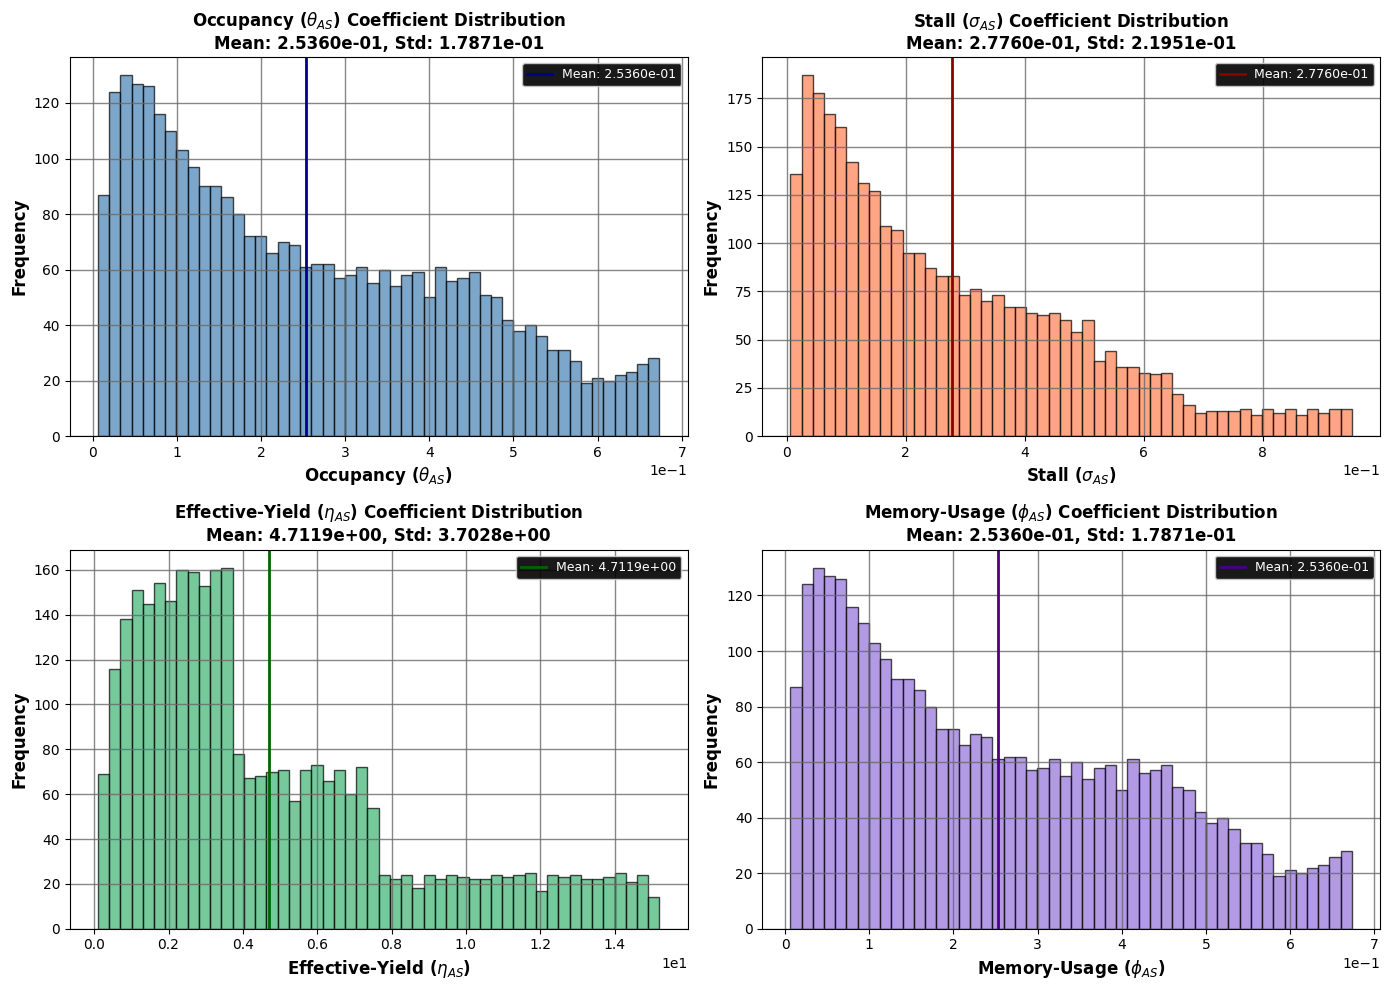

In [17]:
# Plot distributions of the four derived coefficients in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="white")

# Create auxiliary lists for iteration
coeff_data = [theta_sim, sigma_sim, eta_sim, phi_sim]
coeff_names = [
    "Occupancy ($\\boldsymbol{\\theta_{AS}}$)",
    "Stall ($\\boldsymbol{\\sigma_{AS}}$)", 
    "Effective-Yield ($\\boldsymbol{\\eta_{AS}}$)", 
    "Memory-Usage ($\\boldsymbol{\\phi_{AS}}$)"
]
coeff_colors = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]
mean_line_colors = ["darkblue", "darkred", "darkgreen", "indigo"]

# Iterate over grid positions (2x2)
plot_idx = 0
for row in range(2):
    for col in range(2):
        # Set white background for subplot
        axes[row, col].set_facecolor("white")
        
        # Get current data and properties
        data = coeff_data[plot_idx]
        name = coeff_names[plot_idx]
        color = coeff_colors[plot_idx]
        mean_color = mean_line_colors[plot_idx]
        
        # Plot histogram
        axes[row, col].hist(data,
                            bins=50, color=color,
                            alpha=0.7, edgecolor="black")
        
        # Add mean line
        axes[row, col].axvline(np.mean(data),
                               color=mean_color, linestyle="-",
                               linewidth=2,
                               label=f"Mean: {np.mean(data):.4e}")
        
        # Set labels and title with black font
        axes[row, col].set_xlabel(name,
                                  fontsize=12, fontweight="bold",
                                  color="black")
        axes[row, col].set_ylabel("Frequency",
                                  fontsize=12, fontweight="bold",
                                  color="black")
        title = f"{name} Coefficient Distribution"
        title += f"\nMean: {np.mean(data):.4e}, Std: {np.std(data):.4e}"
        axes[row, col].set_title(title,
                                 fontsize=12, fontweight="bold",
                                 color="black")
        
        # Format and style with black font
        axes[row, col].ticklabel_format(axis="x", style="sci", scilimits=(0,0))
        axes[row, col].tick_params(colors="black", which="both")
        axes[row, col].legend(loc="best", fontsize=9, framealpha=0.9)
        axes[row, col].grid(True, alpha=0.8, color="dimgray", linewidth=1.0)
        
        # Set spine colors to black
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor("black")
        
        plot_idx += 1

plt.tight_layout()

# Save figure in both SVG and PNG formats
plt.savefig("img/iter1/dc_data_dist.svg",
            format="svg", dpi=300, bbox_inches="tight")
plt.savefig("img/iter1/dc_data_dist.png",
            format="png", dpi=300, bbox_inches="tight")

plt.show()

## 9. Plot Yoly Diagram

Similar to the Moody diagram for Reynolds number, we can plot the relationship between the coefficients of **Occupancy** ($\theta$), **Stall** ($\sigma$), and **Effective-Yield** ($\eta$) to visualize queue behavior across different configurations.

- **X-axis:** Occupancy $(\theta = L/K)$ - Queue fullness ratio
- **Y-axis:** Stall $(\sigma = W \cdot \lambda / L)$ - Service blocking probability
- **Z-axis:** Effective-Yield $(\eta= \chi \cdot K / (\mu \cdot c))$ - Resource utilization effectiveness
- **Aux-axis:**
- **Color coding:** By number of servers (red=1, orange=2, green=4)

The relationship reveals how queue occupancy directly influences the probability of service stalls across different system configurations.

In [18]:
# Create 3D Yoly diagram
from mpl_toolkits.mplot3d import Axes3D
# Create 2D Yoly diagrams in a 2x2 grid
import matplotlib as mpl

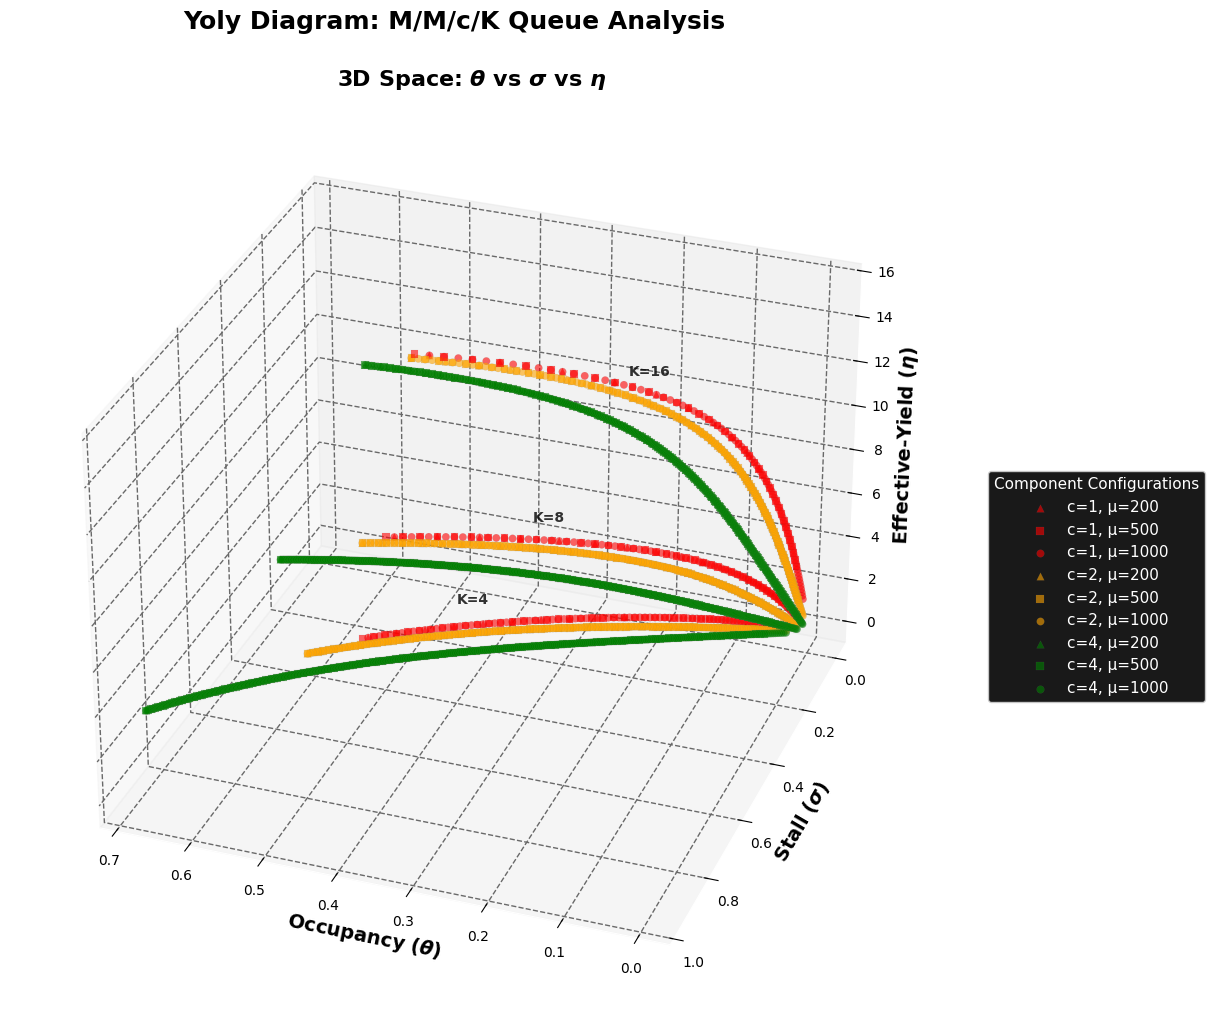

In [19]:
# Set grid color in rcParams before creating figure
mpl.rcParams["grid.color"] = "dimgray"
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["grid.linewidth"] = 1
mpl.rcParams["grid.alpha"] = 0.9

fig = plt.figure(figsize=(14, 12), facecolor="white")

# Create 3D axis
ax = fig.add_subplot(111, projection="3d")

# Data for 3D plot
x_data = theta_sim
y_data = sigma_sim
z_data = eta_sim

# Set white background for subplot
ax.set_facecolor("white")

# Color map for server count (c) and marker map for service rates (μ)
c_data = np.array(variables["c_{AS}"].data)
mu_data = np.array(variables["\\mu_{AS}"].data)
K_data = np.array(variables["K_{AS}"].data)
unique_c = np.unique(c_data)
unique_mu = np.unique(mu_data)
unique_K = np.unique(K_data)

# Colors for servers: red (1), orange (2), green (4)
color_map = {1.0: "red", 2.0: "orange", 4.0: "green"}
# Markers for service rate: triangle (slow), square (mid), circle (fast)
marker_map = {200: "^", 500: "s", 1000: "o"}

# Track which (c, μ) combinations have been labeled for legend
labeled_combinations = set()
# Track which K values have been labeled to avoid duplicates
labeled_K_values = set()

# Plot data points grouped by server count (c), service rate (μ), and capacity (K)
for c_val in unique_c:
    for mu_val in unique_mu:
        for K_val in unique_K:
            # Create mask for this specific combination
            mask = (np.abs(c_data - c_val) < 0.1) & (np.abs(mu_data - mu_val) < 0.1) & (np.abs(K_data - K_val) < 0.1)
            if not np.any(mask):
                continue

            # Create label only once per (c, μ) combination
            combo_key = (c_val, mu_val)
            if combo_key not in labeled_combinations:
                label = f"c={int(c_val)}, μ={int(mu_val)}"
                labeled_combinations.add(combo_key)
            else:
                label = None  # No label for subsequent K values

            color = color_map.get(c_val, "gray")
            marker = marker_map.get(mu_val, "o")

            # 3D scatter plot
            ax.scatter(x_data[mask], y_data[mask], z_data[mask],
                       c=color, marker=marker, s=30, alpha=0.6,
                       edgecolors="grey", linewidths=0.1,
                       label=label)
            # Add K value label only once per unique K value
            if K_val not in labeled_K_values:
                mask_indices = np.where(mask)[0]
                if len(mask_indices) > 0:
                    mid_idx = mask_indices[len(mask_indices)//2]
                    ax.text(x_data[mid_idx]+0.05,
                            y_data[mid_idx]-0.05,
                            z_data[mid_idx]+0.01,
                            f"K={int(K_val)}",
                            fontsize=10, color="black",
                            fontweight="bold", alpha=0.8)
                    labeled_K_values.add(K_val)

# Set labels using public API
ax.set_xlabel("Occupancy ($\\boldsymbol{\\theta}$)",
              fontsize=14, fontweight="bold", color="black")
ax.set_ylabel("Stall ($\\boldsymbol{\\sigma}$)",
              fontsize=14, fontweight="bold", color="black")
ax.set_zlabel("Effective-Yield ($\\boldsymbol{\\eta}$)",
              fontsize=14, fontweight="bold", color="black")

# Set view angle
ax.view_init(elev=30, azim=110)

# Enable grid - it will use the rcParams settings
ax.grid(True)

# Set tick parameters using public API
ax.tick_params(axis="x", colors="black", which="both", labelsize=10)
ax.tick_params(axis="y", colors="black", which="both", labelsize=10)
ax.tick_params(axis="z", colors="black", labelsize=10)   # type: ignore[arg-type]

# Set title with black font
ax.set_title("3D Space: $\\boldsymbol{\\theta}$ vs $\\boldsymbol{\\sigma}$ vs $\\boldsymbol{\\eta}$", 
             fontsize=16, fontweight="bold", color="black")
ax.legend(loc="upper left",
          bbox_to_anchor=(1.05, 0.6), fontsize=11,
          title="Component Configurations",
          title_fontsize=11,
          framealpha=0.9)

# Add main title with black font
fig.suptitle("Yoly Diagram: M/M/c/K Queue Analysis",
             fontsize=18, fontweight="bold", y=0.95, color="black")

# Save figure in both SVG and PNG formats ../assets
plt.savefig("img/iter1/yoly_diagram_3d.svg",
            format="svg", dpi=300, bbox_inches="tight")
plt.savefig("img/iter1/yoly_diagram_3d.png",
            format="png", dpi=300, bbox_inches="tight")

plt.show()

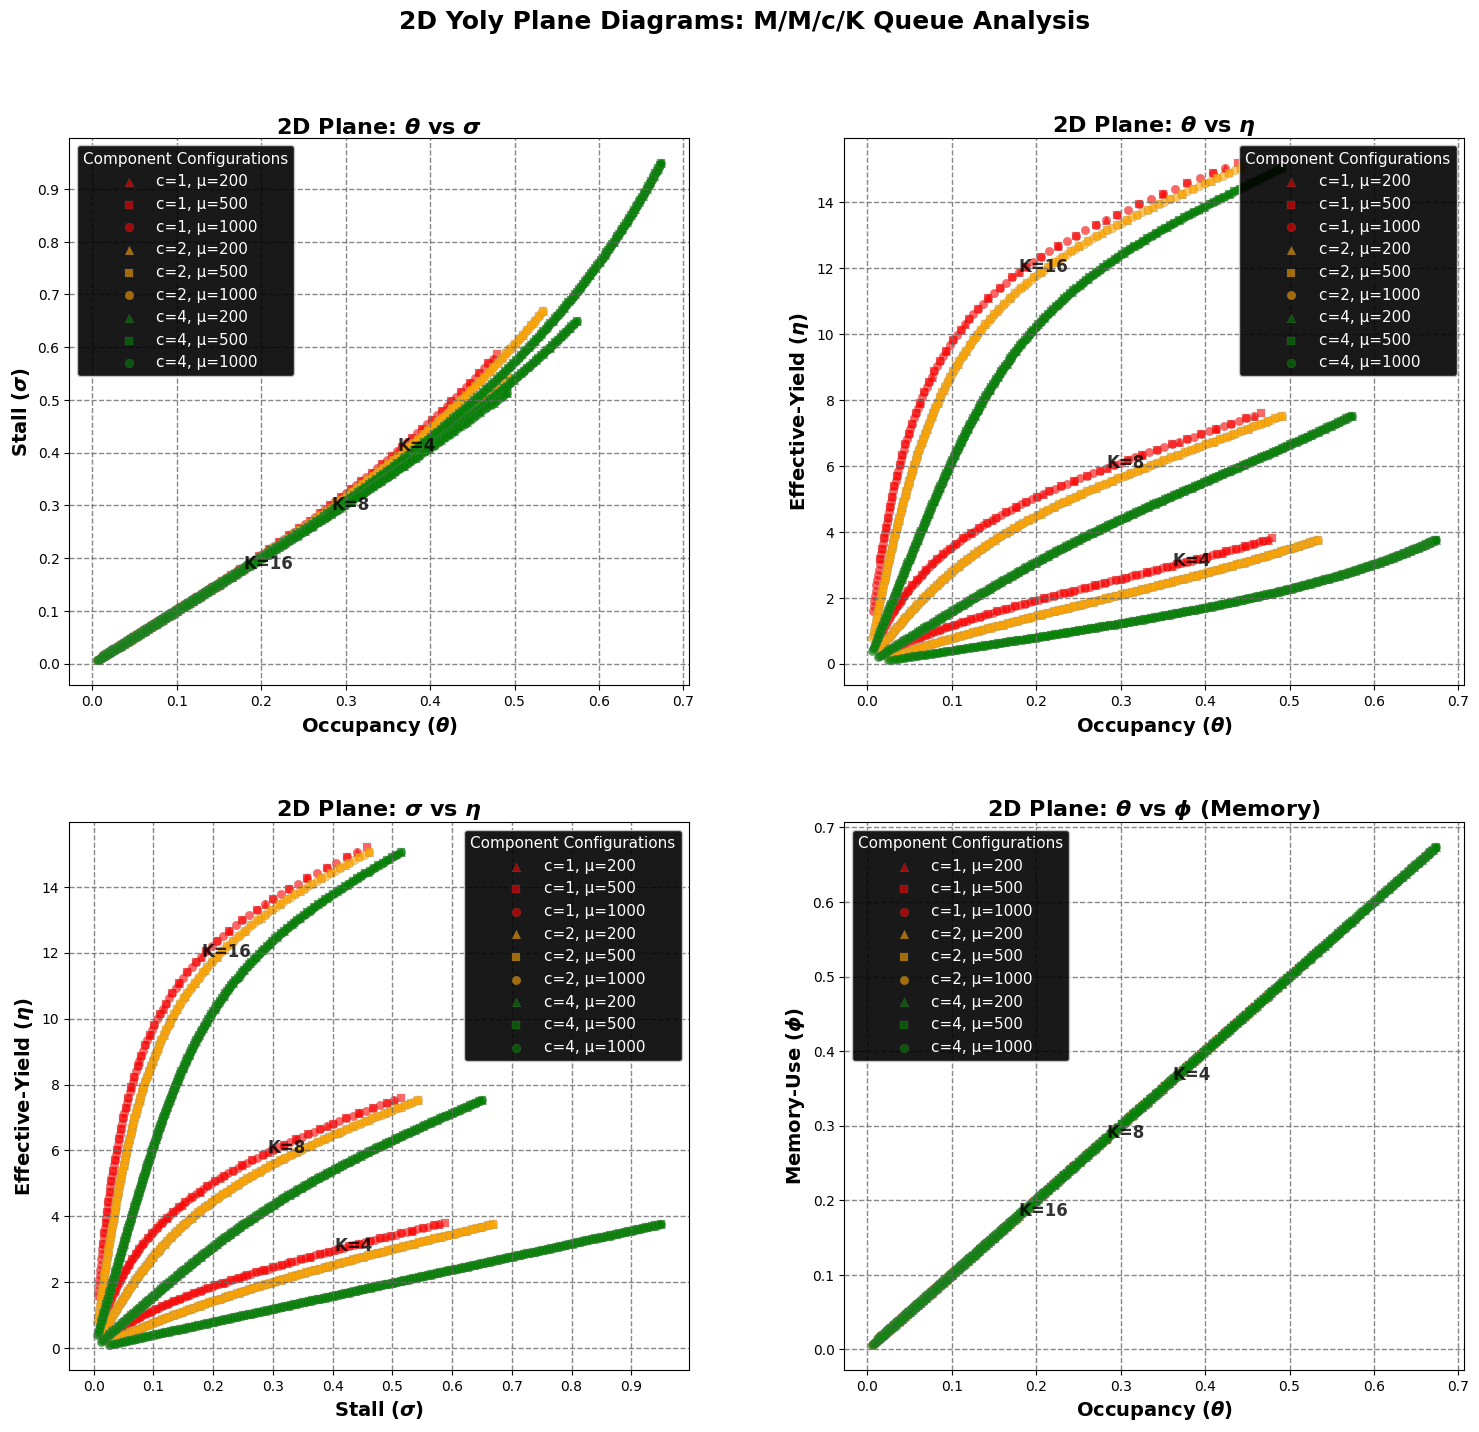

In [20]:
# Set grid color in rcParams
mpl.rcParams["grid.color"] = "dimgray"
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["grid.linewidth"] = 1
mpl.rcParams["grid.alpha"] = 0.8

fig = plt.figure(figsize=(18, 16), facecolor="white")

# Define grid specification for 2 rows x 2 columns layout
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Create 2D axes in a 2x2 grid
ax_11 = fig.add_subplot(gs[0, 0])  # Top Left: θ vs σ
ax_12 = fig.add_subplot(gs[0, 1])  # Top Right: θ vs η
ax_21 = fig.add_subplot(gs[1, 0])  # Bottom Left: σ vs η
ax_22 = fig.add_subplot(gs[1, 1])  # Bottom Right: θ vs φ

# Collect all axes in order for iteration
axes = [ax_11, ax_12, ax_21, ax_22]

# Auxiliary lists for plot configuration
plot_titles = [
    "2D Plane: $\\boldsymbol{\\theta}$ vs $\\boldsymbol{\\sigma}$",
    "2D Plane: $\\boldsymbol{\\theta}$ vs $\\boldsymbol{\\eta}$",
    "2D Plane: $\\boldsymbol{\\sigma}$ vs $\\boldsymbol{\\eta}$",
    "2D Plane: $\\boldsymbol{\\theta}$ vs $\\boldsymbol{\\phi}$ (Memory)"
]

x_labels = [
    "Occupancy ($\\boldsymbol{\\theta}$)",
    "Occupancy ($\\boldsymbol{\\theta}$)",
    "Stall ($\\boldsymbol{\\sigma}$)",
    "Occupancy ($\\boldsymbol{\\theta}$)"
]

y_labels = [
    "Stall ($\\boldsymbol{\\sigma}$)",
    "Effective-Yield ($\\boldsymbol{\\eta}$)",
    "Effective-Yield ($\\boldsymbol{\\eta}$)",
    "Memory-Use ($\\boldsymbol{\\phi}$)"
]

# Data pairs for each subplot: (x_data, y_data)
data_pairs = [
    (theta_sim, sigma_sim),  # 2D: θ vs σ
    (theta_sim, eta_sim),    # 2D: θ vs η
    (sigma_sim, eta_sim),    # 2D: σ vs η
    (theta_sim, phi_sim)     # 2D: θ vs φ
]

# Color map for server count (c) and marker map for service rates (μ)
c_data = np.array(variables["c_{AS}"].data)
mu_data = np.array(variables["\\mu_{AS}"].data)
K_data = np.array(variables["K_{AS}"].data)
unique_c = np.unique(c_data)
unique_mu = np.unique(mu_data)
unique_K = np.unique(K_data)

# Colors for servers: red (1), orange (2), green (4)
color_map = {1.0: "red", 2.0: "orange", 4.0: "green"}
# Markers for service rate: triangle (slow), square (mid), circle (fast)
marker_map = {200: "^", 500: "s", 1000: "o"}

# Iterate over all axes
for plot_idx, ax in enumerate(axes):
    x_data, y_data = data_pairs[plot_idx]
    
    # Set white background for subplot
    ax.set_facecolor("white")
    
    # Track which (c, μ) combinations have been labeled for legend
    labeled_combinations = set()
    # Track which K values have been labeled (only label each K once per plot)
    labeled_K_values = set()
    
    # Plot data points grouped by server count (c), service rate (μ), and capacity (K)
    for c_val in unique_c:
        for mu_val in unique_mu:
            for K_val in unique_K:
                # Create mask for this specific combination
                mask = (np.abs(c_data - c_val) < 0.1) & (np.abs(mu_data - mu_val) < 0.1) & (np.abs(K_data - K_val) < 0.1)
                if not np.any(mask):
                    continue
                
                # Create label only once per (c, μ) combination
                combo_key = (c_val, mu_val)
                if combo_key not in labeled_combinations:
                    label = f"c={int(c_val)}, μ={int(mu_val)}"
                    labeled_combinations.add(combo_key)
                else:
                    label = None  # No label for subsequent K values
                
                color = color_map.get(c_val, "gray")
                marker = marker_map.get(mu_val, "o")
                
                # 2D scatter plot
                ax.scatter(x_data[mask],
                           y_data[mask],
                           c=color, marker=marker, s=40, alpha=0.6,
                           edgecolors="grey", linewidths=0.2,
                           label=label)
                # Add K value label only once per unique K value
                if K_val not in labeled_K_values:
                    mask_indices = np.where(mask)[0]
                    if len(mask_indices) > 0:
                        mid_idx = mask_indices[len(mask_indices)//2]
                        ax.text(x_data[mid_idx],
                                y_data[mid_idx], 
                                f"K={int(K_val)}", fontsize=12, color="black",
                                fontweight="bold", alpha=0.8)
                        labeled_K_values.add(K_val)
    
    # 2D styling
    ax.grid(True, alpha=0.8,
            color="dimgray", linewidth=1.0,
            linestyle="--")
    ax.tick_params(colors="black", which="both", labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
    
    # Set consistent tick spacing only for X axis (theta has consistent range)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    
    # Set Y axis tick spacing only for plot 0 (Occupancy vs Stall)
    if plot_idx == 0:
        ax.yaxis.set_major_locator(MultipleLocator(0.1))

    # Set labels and title with black font
    ax.set_xlabel(x_labels[plot_idx], fontsize=14,
                  fontweight="bold", color="black")
    ax.set_ylabel(y_labels[plot_idx], fontsize=14,
                  fontweight="bold", color="black")
    ax.set_title(plot_titles[plot_idx], fontsize=16,
                 fontweight="bold", pad=-10, color="black")
    
    # Position legend inside the plot
    ax.legend(loc="best", fontsize=11,
              framealpha=0.9,
              title="Component Configurations",
              title_fontsize=11)

# Add main title with black font
fig.suptitle("2D Yoly Plane Diagrams: M/M/c/K Queue Analysis",
             fontsize=18, fontweight="bold", y=0.96, color="black")

# Save figure in both SVG and PNG formats
plt.savefig("img/iter1/yoly_diagram_2d.svg",
            format="svg", dpi=300, bbox_inches="tight")
plt.savefig("img/iter1/yoly_diagram_2d.png",
            format="png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:

# Print summary statistics
print("=" * 80)
print("COMPREHENSIVE YOLY DIAGRAM STATISTICS")
print("=" * 80)
print(f"{'Metric':<20} {'Mean':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12}")
print("-" * 80)
print(f"{'Occupancy (θ)':<20} {np.mean(theta_sim):<12.4f} {np.std(theta_sim):<12.4f} {np.min(theta_sim):<12.4f} {np.max(theta_sim):<12.4f}")
print(f"{'Stall (σ)':<20} {np.mean(sigma_sim):<12.4f} {np.std(sigma_sim):<12.4f} {np.min(sigma_sim):<12.4f} {np.max(sigma_sim):<12.4f}")
print(f"{'Effective-Yield (η)':<20} {np.mean(eta_sim):<12.4f} {np.std(eta_sim):<12.4f} {np.min(eta_sim):<12.4f} {np.max(eta_sim):<12.4f}")
print(f"{'Memory-Use (φ)':<20} {np.mean(phi_sim):<12.4f} {np.std(phi_sim):<12.4f} {np.min(phi_sim):<12.4f} {np.max(phi_sim):<12.4f}")
print("=" * 80)

print(f"\nConfiguration Distribution:")
print(90 * "-")
print(f"{'Servers (c)':<12} {'Service Rate (μ)':<17} {'Capacity (K)':<14} {'Marker':<10} {'Color':<10} {'Count':<10} {'Percentage':<10}")
print(90 * "-")
for c_val in unique_c:
    for mu_val in unique_mu:
        for K_val in unique_K:
            mask = (np.abs(c_data - c_val) < 0.1) & (np.abs(mu_data - mu_val) < 0.1) & (np.abs(K_data - K_val) < 0.1)
            count = np.sum(mask)
            if count > 0:
                marker = marker_map.get(mu_val, "o")
                marker_name = {"^": "Triangle", "s": "Square", "o": "Circle"}.get(marker, "Unknown")
                color_name = {1.0: "Red", 2.0: "Orange", 4.0: "Green"}.get(c_val, "Gray")
                percentage = 100 * count / len(mu_data)
                print(f"{int(c_val):<12} {int(mu_val):<17} {int(K_val):<14} {marker_name:<10} {color_name:<10} {count:<10} {percentage:.1f}%")
print(90 * "-")

COMPREHENSIVE YOLY DIAGRAM STATISTICS
Metric               Mean         Std Dev      Min          Max         
--------------------------------------------------------------------------------
Occupancy (θ)        0.2536       0.1787       0.0063       0.6735      
Stall (σ)            0.2776       0.2195       0.0063       0.9500      
Effective-Yield (η)  4.7119       3.7028       0.0990       15.2064     
Memory-Use (φ)       0.2536       0.1787       0.0063       0.6735      

Configuration Distribution:
------------------------------------------------------------------------------------------
Servers (c)  Service Rate (μ)  Capacity (K)   Marker     Color      Count      Percentage
------------------------------------------------------------------------------------------
1            200               4              Triangle   Red        10         0.3%
1            200               8              Triangle   Red        10         0.3%
1            200               16             T

## 10. Work Summary

This notebook demonstrated PyDASA's dimensional analysis workflows applied to queueing theory and software service analysis using the M/M/c/K queue model:

1. **Custom Dimensional Framework:** Created a specialized framework with three fundamental dimensions (T, S, D) for software service analysis - Time, Structure, and Data.
2. **Variable Definition:** Defined 10 queue system variables including arrival rate ($\lambda$), service rate ($\mu$), queue capacity ($K$), servers ($c$), and error rate ($\text{err}$).
3. **Dimensional Analysis:** Automatically generated 6 dimensionless $\Pi$-groups using Buckingham $\Pi$-theorem with custom dimensions, and semi-automated symbolic simplification derive 4 more coefficients.
4. **Derived Coefficient:** Created from the original 6 $\Pi$-groups:
   - **Occupancy:** $\theta = L/K$ for the Queue capacity utilization.
   - **Stall:** $\sigma = W \cdot \lambda / L$ for the Service blocking indicator.
   - **Effective-Yeild:** $\eta = \chi \cdot K / (\mu \cdot c)$ for the Resource utilization effectiveness.
   - **Memory-Use:** $\phi = M_{\text{act}} / M_{\text{buf}}$ for the memory usage metric.
5. **Sensitivity Analysis:** Symbolic analysis showing which variables most influence each dimensionless coefficient.
6. **Grid-Based Monte Carlo:** Generated structured data points systematically varying:
   1. **Variables:**
      - Queue capacity $(K)$: [5, 10, 20] → 3 values
      - Service rate $(\mu)$: [200, 500, 1000] req/s → 3 values  
      - Server count $(c)$: [1, 2, 4] → 3 values
      - Request data density $(\rho_{\text{req}})$ based on the queue-memory ratio formula $B = \rho_{req} \cdot L$ for simulation consistency.
      - Total Configurations: 3 × 3 × 3 = _**27 configurations**_
   2. **Constants:**
     - Component error rate $\text{err} = 1.0\%$
     - Max Buffer Memory $M_{\text{buf}} = 2.56 \times 10^8$ bits
7. **Visualization:** Created comprehensive visualizations including:
   - **2×2 histogram grid:** Distribution plots for all four derived coefficients ($\theta, \sigma, \eta, \phi$) with LaTeX-formatted symbols and mean lines.
   - **Comprehensive Yoly diagram (2×2 grid):**
     - 3D scatter plot ($\theta$ vs $\sigma$ vs $\eta$) with server-based color coding and $K$-value labels.
     - Three 2D projection plots showing relationships between coefficient pairs:
       - $\theta$ vs $\sigma$ (Occupancy vs Stall)
       - $\theta$ vs $\eta$ (Occupancy vs Effective-Yeild)
       - $\sigma$ vs $\eta$ (Stall vs Effective-Yeild)

### Key PyDASA Workflows

```python
# 1. Custom Schema Definition
schema = Schema(_fwk="CUSTOM", _fdu_lt=fdu_list, ...)
schema._setup_fdus()

# 2. Dimensional Analysis
engine = AnalysisEngine(_fwk="CUSTOM", _schema=schema, ...)
engine.run_analysis()

# 3. Derive Coefficients
delta_coeff = engine.derive_coefficient(
    expr=f"{pi_keys[0]}", 
    symbol="\\theta",
    name="Occupancy Coefficient", ...)

# 4. Sensitivity Analysis
sensitivity = SensitivityAnalysis(_cat="SYM", ...)
sensitivity_results = sensitivity.analyze_symbolic(val_type="mean")

# 5. Monte Carlo Simulation
mc_grid = MonteCarloSimulation(
    _cat="DATA",  # Use actual data from grid search
    _experiments=len(data_df), ...)
mc_grid.run_simulation(iters=len(data_df))
```

### Features Demonstrated

✓ Custom dimensional frameworks beyond physical dimensions  
✓ Software/service system dimensional analysis  
✓ Queueing theory (M/M/c/K) integration with PyDASA  
✓ Grid-based systematic data generation with 27 configurations  
✓ Coefficient derivation with symbolic expressions  
✓ Symbolic sensitivity analysis  
✓ 3D and 2D visualization with matplotlib  

## 11. Insights

### Coefficients Vs. Metrics

Traditional queueing theory uses **utilization** $\rho = \lambda/(\mu \cdot c)$ to measure server busy-time. This is a dimensional metric that doesn't account for capacity limits, error rates, or temporal inefficiencies.

Our dimensionless coefficients provide orthogonal views for:

- **Occupation** $\theta = L/K$: Instantaneous queue fullness (spatial measure).
- **Stall** $\sigma = W \cdot \lambda / L$: Delay-throughput coupling (temporal inefficiency).
- **Effective-Yield** $\eta = \chi \cdot K / (\mu \cdot c)$: with Error-aware resource effectiveness using $\chi = (1-\text{err})\lambda$.
- **Memory-Use** $\phi = M_{\text{act}} / M_{\text{buf}}$: Data dimension saturation.

Unlike $\rho$, which only tracks server state, these coefficients capture system-wide behavior across Time, Structure, and Data dimensions. Two systems with identical $\rho = 0.6$ can exhibit drastically different $\sigma$ values—one smooth, one congested; thus, revealing inefficiencies invisible to traditional metrics.

### Interpreting the Yoly Chart

This Yoly chart maps 27 different configurations into dimensionless $(\theta, \sigma, \eta)$ space, revealing scaling laws:

- **Safe Operating Zone:** Near the **origin** ($\theta < 0.3$, $\sigma < 0.3$), systems maintain stable, predictable performance. In this regime, **Effective-Yield** $\eta$ exhibits **approximately linear behavior** with load vs. resource consumption scales predictably and in small poroportions, allowing confident extrapolation.
- **Failure Boundary:** $\eta$ undergoes a dip moving toward high $\theta$ and high $\sigma$. This signals an imminent saturation otherwise or **nonlinear degradation**. Small load chages trigger disproportionate resource consumption as queues approach full capacity $K$.
- **Master Curves:** Despite wildly different dimensional parameters $(K, c, \mu)$, configurations collapse onto certain _Master Curves_ (following $c$ count). This proves than dimensionless ratios are useful. Server count $c$ determines which curve family is; while capacity $K$ and service rate $\mu$ select position along that curve.
- **Color Clustering:** Red ($c=1$), orange ($c=2$), green ($c=4$) separate server families vertically. Configurations near origin are efficient designs; outliers at high $(\theta, \sigma)$ indicate over-utilized, failure-prone systems.

### Using the Yoly Chart

- **Design Point Selection:** Target low-$\theta$, low-$\sigma$ region where $\eta$ is linear. Visually identify safe zones and read required $(K, c, \mu)$ combinations directly from the chart, reducing the trial and error tasks.
- **Load Forecasting:** If arrival rate $\lambda$ increases 50%, trace the trajectory along the master curve. If it moves away from origin into high-$\theta$/high-$\sigma$ territory, capacity upgrades are needed *before* QoS violations occur.
- **Failure Prediction:** Trajectories approaching $\theta \to 1$ show accelerating $\sigma$ growth (stall divergence) and nonlinear $\eta$ degradation. The dip in $\eta$ provides quantitative early warning of saturation-induced collapse.
- **Configuration Comparison:** Untested parameter combinations can be interpolated from neighboring points. If interpolation places a candidate design near origin, it's safe; if far from origin, it risks failure under load.
- **Alternative configurations:** Using the axis of the plot reveal alternative component configurations than can accomplish 

**Scaling Strategy:** 
- Doubling servers ($c$: 1→2→4) moves to different master curve closer to origin
- Increasing $K$ or $\mu$ shifts position along same curve toward origin
- Choose $c$ first (architectural decision), then tune $K$/$\mu$ for cost-performance balance

### Practical Implications

- Operational workflow for software systems include:
  1. **Monitor:** Calculate $(\theta, \sigma, \eta)$ from telemetry ($L$, $W$, $\lambda$, etc.)
  2. **Locate:** Plot current operating point on Yoly chattive to origin
  3. **Diagnose:** If drifting away from origin, system entering nonlinear regime
  4. **Prescribe:** Increase $c$ (move curve families) or $K$/$\mu$ (shift along curve)
  5. **Validate:** Simulate changes to confirm they restore operation near origin
- *Design Principle:** Stay in the linear $\eta$ regime near origin where performance is predictable and failures are far from operating point. High $\theta$/$\sigma$ configurations trade efficiency for fragility.
- **Universality:** Results scale across domains—microservice (10 req/s) and datacenter (10⁶ req/s) share the same Yoly map if dimensionless parameters align. Cost optimization becomes minimizing $\eta$ while maintaining $(\theta, \sigma)$ constraints.
- **Early Warning:** Monitor distance from origin. Small drift indicates degrading margin; large drift signals imminent failure. Unlike dimensional metrics that require domain-specific thresholds, dimensionless coefficients provide universal boundaries: $\theta < 0.3$ and $\sigma < 0.3$ define safe operation regardless of scale.

### Next Steps

- Extend analysis to other queueing models (M/G/1, G/G/c, priority queues, etc.)
- Incorporate time-varying arrival rates and non-stationary behavior
- Add cost-based optimization using dimensionless coefficients (\$/request vs. $\eta$)
- Explore other custom frameworks (Security, Latency, Reliability dimensions)
- Apply to real-world service telemetry data from production systems
- Investigate multi-objective optimization across all four coefficients ($\theta, \sigma, \eta, \phi$)
- Develop predictive models using dimensionless regression
- Map the linear-to-nonlinear transition boundary quantitatively for different $(c, K, \mu)$ families

Check [PyDASA Documentation](https://pydasa.readthedocs.io) for advanced features and more examples.

---

**About this notebook:** Created to demonstrate PyDASA's dimensional analysis workflows applied to queueing theory and software service analysis using custom dimensional frameworks. The "Yoly" concept represents a composite metric for system happiness (performance + availability + efficiency + reliability). For more examples and documentation, visit [PyDASA on GitHub](https://github.com/DASA-Design/PyDASA) or [Read the Docs](https://pydasa.readthedocs.io).

M/M/c/K System Diagram

```
                    ┌─────────────────────────────────────────────────────┐
                    │  M/M/c/K System (Capacity = K)                      │
                    │                                                     │
  Arrivals (λ)      │     Queue          Servers (μ)      Response (χ)    │
  [S/T]             │   ┌─┬─┬─┐                                           │
                    │   │ │ │ │                                           │
    ● ● ●  ─────────┼──→│ │ │ │─────→  Server 1 (μ) ────────────────────→ ●    Served
    ● ● ●           │   └─┴─┴─┘    ╱                                      │  Requests
    ● ● ●           │    (K-c)    ╱                                       │  χ = (1-err)·λ
  (Poisson)         │   slots    ●─────→  Server 2 (μ) ───────────────→ ● │  [S/T]
                    │           ╲                                         │
  When FULL:        │            ╲                                        │
    ● ● ●  ─────X   │             ────→  Server c (μ) ─────────────────→ ●│
                    │                                                     │
  Blocked/          │  ↑____________________________________________↑     │
  Rejected          │         K = Total Capacity (queue + servers)        │
                    │                                                     │
  Error Rate (err)  │  Note: χ = (1 - err) · λ                            │
  Affects Response  │  Some requests fail → reduces effective throughput  │
  [%]               │                                                     │
                    └─────────────────────────────────────────────────────┘
                    
  Legend:
  - λ (lambda): Arrival rate [S/T]
  - μ (mu): Service rate per server [S/T]
  - c: Number of parallel servers [S]
  - K: Total capacity (queue + servers) [S]
  - χ (chi): Effective response rate = (1 - err) · λ [S/T]
  - err: Error/failure rate [%, 0 to 1]
```